<a href="https://colab.research.google.com/github/TranQuocHuy83/mlops_training---module03---HuyTran-/blob/main/04_multi_class_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Exercise 4: Multi-Class Classification
Neural Network Classification - Module 3

This exercise covers:
- Creating multi-class data with make_blobs
- Building multi-class models
- Using CrossEntropyLoss
- Converting logits with softmax
- Using argmax for predictions

Learning Mottos:
- If in doubt, run the code!
- Experiment, experiment, experiment!
- Visualize, visualize, visualize!
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ============================================
# Part 1: Creating make_blobs Dataset
# ============================================

In [8]:
print("=" * 60)
print("Part 1: Creating make_blobs Dataset")
print("=" * 60)

# TODO: Create make_blobs dataset
n_samples = 1000
n_classes = 4

X, y = make_blobs(
    n_samples=n_samples,
    n_features=2,
    centers=n_classes,
    cluster_std=1.5,
    random_state=42
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(set(y))}")

for class_id in range(n_classes):
    print(f"  Class {class_id}: {sum(y == class_id)} samples")

Part 1: Creating make_blobs Dataset
X shape: (1000, 2)
y shape: (1000,)
Number of classes: 4
  Class 0: 250 samples
  Class 1: 250 samples
  Class 2: 250 samples
  Class 3: 250 samples


# ============================================
# Part 2: Visualizing the Data
# ============================================


Part 2: Visualizing the Data


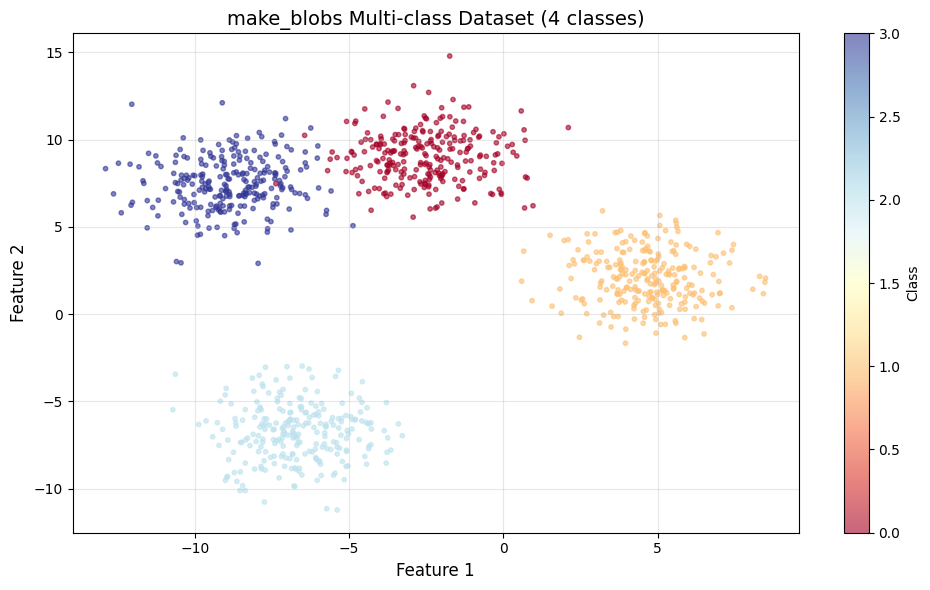

Visualization created!
Motto: Visualize, visualize, visualize!


In [9]:
print("\n" + "=" * 60)
print("Part 2: Visualizing the Data")
print("=" * 60)

# TODO: Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.6)
plt.title(f'make_blobs Multi-class Dataset ({n_classes} classes)', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Class')
plt.tight_layout()
plt.show()

print("Visualization created!")
print("Motto: Visualize, visualize, visualize!")

# ============================================
# Part 3: Train/Test Split and Conversion
# ============================================

In [10]:
print("\n" + "=" * 60)
print("Part 3: Train/Test Split and Conversion")
print("=" * 60)

# TODO: Split data (stratified for multi-class)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# TODO: Convert to PyTorch tensors
# IMPORTANT: For multi-class, y should be LongTensor (class indices)
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

# Move to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

print(f"\nTensor shapes:")
print(f"X_train: {X_train.shape}, dtype: {X_train.dtype}")
print(f"y_train: {y_train.shape}, dtype: {y_train.dtype}")
print(f"X_test: {X_test.shape}, dtype: {X_test.dtype}")
print(f"y_test: {y_test.shape}, dtype: {y_test.dtype}")


Part 3: Train/Test Split and Conversion
Training size: 800
Test size: 200

Using device: cpu

Tensor shapes:
X_train: torch.Size([800, 2]), dtype: torch.float32
y_train: torch.Size([800]), dtype: torch.int64
X_test: torch.Size([200, 2]), dtype: torch.float32
y_test: torch.Size([200]), dtype: torch.int64


# ============================================
# Part 4: Building Multi-Class Model
# ============================================

In [11]:
print("\n" + "=" * 60)
print("Part 4: Building Multi-Class Model")
print("=" * 60)

# TODO: Define multi-class model
class BlobModel(nn.Module):
    """Multi-class classifier"""
    def __init__(self, input_size=2, hidden_size=16, num_classes=4):
        super(BlobModel, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
            # Note: No softmax here (output is logits)
        )

    def forward(self, x):
        return self.layer_stack(x)

model = BlobModel(input_size=2, hidden_size=16, num_classes=n_classes)
model = model.to(device)

print("BlobModel (Multi-class):")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")


Part 4: Building Multi-Class Model
BlobModel (Multi-class):
BlobModel(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=4, bias=True)
  )
)

Total parameters: 116


# ============================================
# Part 5: Loss Function and Optimizer
# ============================================

In [12]:
print("\n" + "=" * 60)
print("Part 5: Loss Function and Optimizer")
print("=" * 60)

# TODO: Use CrossEntropyLoss for multi-class
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(f"Loss function: CrossEntropyLoss()")
print(f"Optimizer: Adam (lr=0.01)")

print("\nKey differences from binary:")
print("  - Binary: BCEWithLogitsLoss, y is FloatTensor with shape [N, 1]")
print("  - Multi-class: CrossEntropyLoss, y is LongTensor with shape [N]")


Part 5: Loss Function and Optimizer
Loss function: CrossEntropyLoss()
Optimizer: Adam (lr=0.01)

Key differences from binary:
  - Binary: BCEWithLogitsLoss, y is FloatTensor with shape [N, 1]
  - Multi-class: CrossEntropyLoss, y is LongTensor with shape [N]


# ============================================
# Part 6: Training Loop
# ============================================

In [13]:

print("\n" + "=" * 60)
print("Part 6: Training Loop")
print("=" * 60)

epochs = 100
train_losses = []
train_accuracies = []

model.train()
for epoch in range(epochs):
    # Forward pass
    y_logits = model(X_train)

    # Calculate loss
    loss = criterion(y_logits, y_train)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track metrics
    train_losses.append(loss.item())
    with torch.no_grad():
        y_pred = torch.argmax(y_logits, dim=1)
        accuracy = (y_pred == y_train).float().mean()
        train_accuracies.append(accuracy.item())

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Acc: {accuracy.item()*100:.2f}%')

print("\nTraining complete!")


Part 6: Training Loop
Epoch [10/100], Loss: 0.4020, Acc: 83.63%
Epoch [20/100], Loss: 0.1678, Acc: 99.25%
Epoch [30/100], Loss: 0.0880, Acc: 98.50%
Epoch [40/100], Loss: 0.0564, Acc: 99.12%
Epoch [50/100], Loss: 0.0426, Acc: 99.12%
Epoch [60/100], Loss: 0.0366, Acc: 99.25%
Epoch [70/100], Loss: 0.0331, Acc: 99.25%
Epoch [80/100], Loss: 0.0307, Acc: 99.25%
Epoch [90/100], Loss: 0.0288, Acc: 99.25%
Epoch [100/100], Loss: 0.0275, Acc: 99.25%

Training complete!


# ============================================
# Part 7: The Logits → Softmax → Argmax Pipeline
# ============================================

In [14]:
print("\n" + "=" * 60)
print("Part 7: Logits → Probabilities → Labels Pipeline")
print("=" * 60)

# Make predictions
model.eval()
with torch.inference_mode():
    test_logits = model(X_test)

    # Convert to probabilities using softmax
    test_probs = torch.softmax(test_logits, dim=1)

    # Convert to labels using argmax
    test_preds = torch.argmax(test_probs, dim=1)

# Show examples
print("\nFirst 3 predictions:")
for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"  Logits: {test_logits[i].cpu().numpy()}")
    print(f"  Probabilities: {test_probs[i].cpu().numpy()}")
    print(f"  Predicted: {test_preds[i].item()}, Actual: {y_test[i].item()}")

# Calculate test accuracy
test_accuracy = (test_preds == y_test).float().mean()
print(f"\nTest Accuracy: {test_accuracy.item()*100:.2f}%")


Part 7: Logits → Probabilities → Labels Pipeline

First 3 predictions:

Sample 1:
  Logits: [-5.6822906 -4.385443   5.193898  -3.7657673]
  Probabilities: [1.8898938e-05 6.9127462e-05 9.9978346e-01 1.2846143e-04]
  Predicted: 2, Actual: 2

Sample 2:
  Logits: [ 0.61010844  9.1367655  -5.409243   -8.655636  ]
  Probabilities: [1.9807681e-04 9.9980146e-01 4.8157318e-07 1.8740124e-08]
  Predicted: 1, Actual: 1

Sample 3:
  Logits: [ -4.511322  -11.180925   -5.7223134   2.003333 ]
  Probabilities: [1.4787207e-03 1.8763515e-06 4.4051351e-04 9.9807894e-01]
  Predicted: 3, Actual: 3

Test Accuracy: 99.50%


# ============================================
# Part 8: Decision Boundary Visualization
# ============================================


Part 8: Decision Boundary Visualization


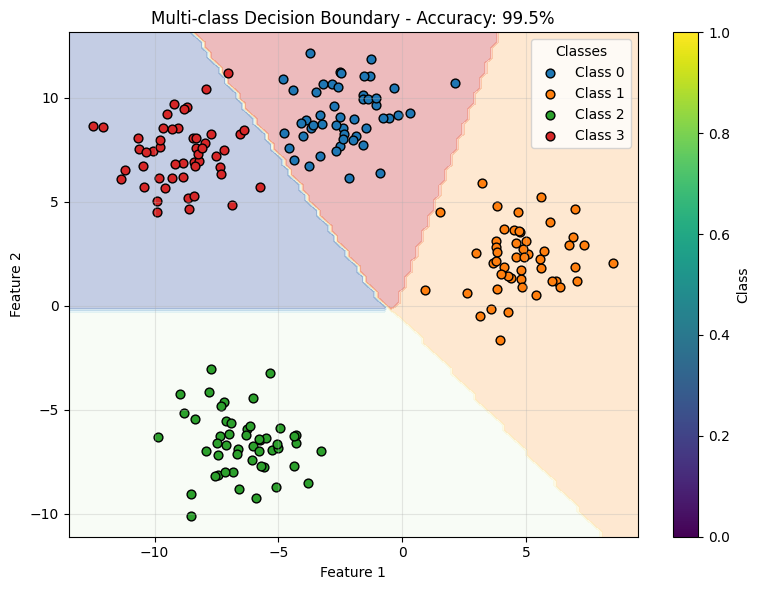

In [19]:
print("\n" + "=" * 60)
print("Part 8: Decision Boundary Visualization")
print("=" * 60)

def plot_multi_class_decision_boundary(model, X, y, title):
    """Plot decision boundary for multi-class model"""
    model.eval()

    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    # Make predictions on meshgrid
    mesh = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    with torch.inference_mode():
        Z = torch.argmax(model(mesh), dim=1).reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z.cpu().numpy(), alpha=0.3, cmap='RdYlBu')
    # Plot each class separately to get legend
    classes = np.unique(y)

    for cls in classes:
        plt.scatter(
            X[y == cls, 0],
            X[y == cls, 1],
            s=40,
            edgecolors='k',
            label=f'Class {cls}'
        )
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.colorbar(label='Class')
    plt.tight_layout()
    plt.legend(title="Classes")
    plt.show()

# Plot decision boundary
X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy()

plot_multi_class_decision_boundary(
    model, X_test_np, y_test_np,
    f'Multi-class Decision Boundary - Accuracy: {test_accuracy.item()*100:.1f}%'
)

# ============================================
# Part 9: Per-Class Accuracy
# ============================================

In [16]:
print("\n" + "=" * 60)
print("Part 9: Per-Class Accuracy")
print("=" * 60)

for class_id in range(n_classes):
    class_mask = y_test == class_id
    class_acc = (test_preds[class_mask] == y_test[class_mask]).float().mean()
    print(f"Class {class_id} Accuracy: {class_acc.item()*100:.2f}%")


Part 9: Per-Class Accuracy
Class 0 Accuracy: 100.00%
Class 1 Accuracy: 100.00%
Class 2 Accuracy: 100.00%
Class 3 Accuracy: 98.00%


# ============================================
# Exercises
# ============================================

In [ ]:
print("\n" + "=" * 60)
print("Exercises")
print("=" * 60)

# Exercise 1: Vary number of classes
print("\nExercise 1: Vary number of classes")
print("Try different numbers of classes:")
print("  - n_classes=2 (binary)")
print("  - n_classes=3")
print("  - n_classes=4 (default)")
print("  - n_classes=5")
print("Tip: Modify the 'n_classes' and 'centers' parameters")

X shape: (1000, 2)
y shape: (1000,)
Number of classes: 2
  Class 0: 500 samples
  Class 1: 500 samples


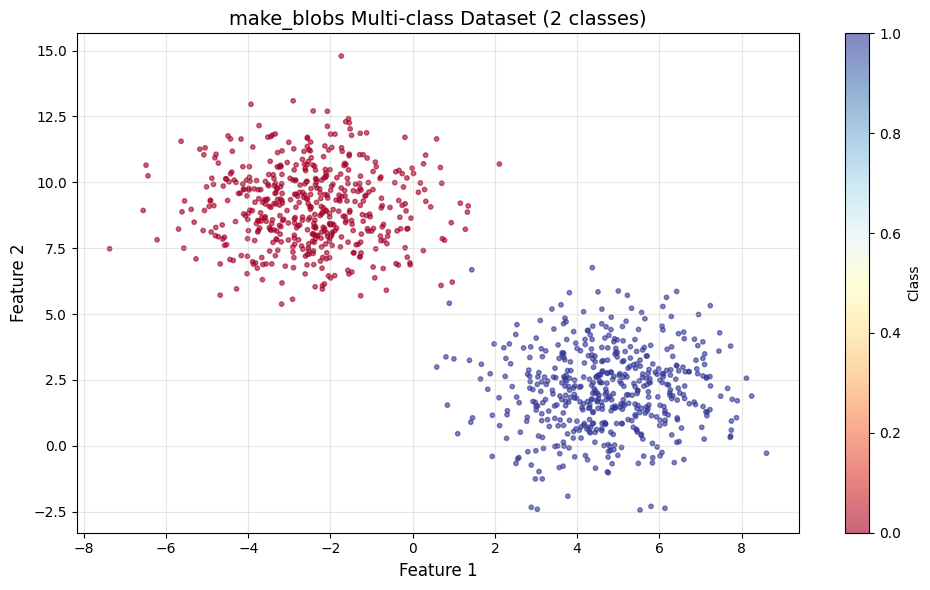

Training size: 800
Test size: 200

Using device: cpu
Epoch [10/100], Loss: 0.0522, Acc: 99.37%
Epoch [20/100], Loss: 0.0161, Acc: 99.50%
Epoch [30/100], Loss: 0.0099, Acc: 99.75%
Epoch [40/100], Loss: 0.0075, Acc: 99.75%
Epoch [50/100], Loss: 0.0060, Acc: 99.75%
Epoch [60/100], Loss: 0.0046, Acc: 100.00%
Epoch [70/100], Loss: 0.0038, Acc: 99.87%
Epoch [80/100], Loss: 0.0032, Acc: 100.00%
Epoch [90/100], Loss: 0.0028, Acc: 100.00%
Epoch [100/100], Loss: 0.0025, Acc: 100.00%

Training complete!

First 3 predictions:

Sample 1:
  Logits: [-12.162309  10.911179]
  Probabilities: [9.534814e-11 1.000000e+00]
  Predicted: 1, Actual: 1

Sample 2:
  Logits: [ 5.1927657 -4.124154 ]
  Probabilities: [9.9991012e-01 8.9882335e-05]
  Predicted: 0, Actual: 0

Sample 3:
  Logits: [ 1.0808464 -1.3765776]
  Probabilities: [0.92110264 0.07889733]
  Predicted: 0, Actual: 0

Test Accuracy: 100.00%


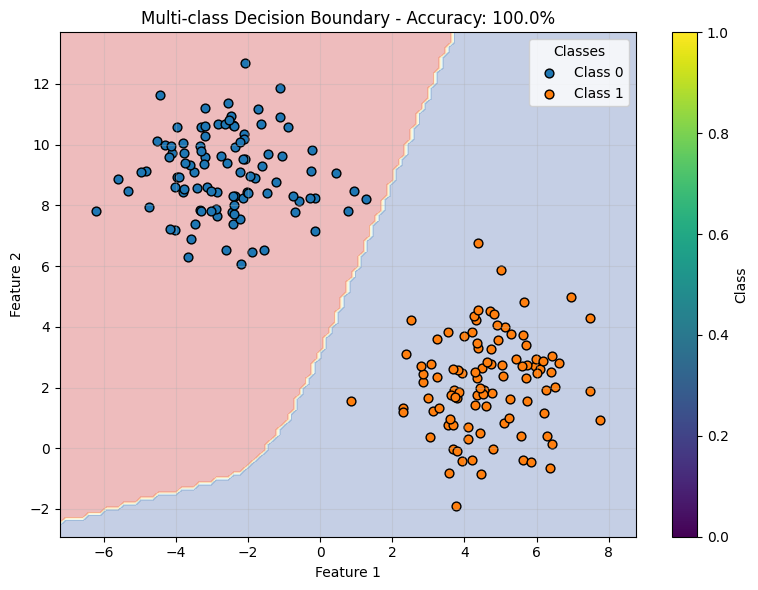

Class 0 Accuracy: 100.00%
Class 1 Accuracy: 100.00%


In [20]:
# N_CLASS = 2
# TODO: Create make_blobs dataset
n_samples = 1000
n_classes = 2

X, y = make_blobs(
    n_samples=n_samples,
    n_features=2,
    centers=n_classes,
    cluster_std=1.5,
    random_state=42
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(set(y))}")

for class_id in range(n_classes):
    print(f"  Class {class_id}: {sum(y == class_id)} samples")

# TODO: Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.6)
plt.title(f'make_blobs Multi-class Dataset ({n_classes} classes)', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Class')
plt.tight_layout()
plt.show()

# TODO: Split data (stratified for multi-class)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# TODO: Convert to PyTorch tensors
# IMPORTANT: For multi-class, y should be LongTensor (class indices)
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

# Move to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
# TODO: Define multi-class model
class BlobModel(nn.Module):
    """Multi-class classifier"""
    def __init__(self, input_size=2, hidden_size=16, num_classes=2):
        super(BlobModel, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
            # Note: No softmax here (output is logits)
        )

    def forward(self, x):
        return self.layer_stack(x)

model = BlobModel(input_size=2, hidden_size=16, num_classes=n_classes)
model = model.to(device)

# TODO: Use CrossEntropyLoss for multi-class
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
train_losses = []
train_accuracies = []

model.train()
for epoch in range(epochs):
    # Forward pass
    y_logits = model(X_train)

    # Calculate loss
    loss = criterion(y_logits, y_train)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track metrics
    train_losses.append(loss.item())
    with torch.no_grad():
        y_pred = torch.argmax(y_logits, dim=1)
        accuracy = (y_pred == y_train).float().mean()
        train_accuracies.append(accuracy.item())

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Acc: {accuracy.item()*100:.2f}%')

print("\nTraining complete!")

# Make predictions
model.eval()
with torch.inference_mode():
    test_logits = model(X_test)

    # Convert to probabilities using softmax
    test_probs = torch.softmax(test_logits, dim=1)

    # Convert to labels using argmax
    test_preds = torch.argmax(test_probs, dim=1)

# Show examples
print("\nFirst 3 predictions:")
for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"  Logits: {test_logits[i].cpu().numpy()}")
    print(f"  Probabilities: {test_probs[i].cpu().numpy()}")
    print(f"  Predicted: {test_preds[i].item()}, Actual: {y_test[i].item()}")

# Calculate test accuracy
test_accuracy = (test_preds == y_test).float().mean()
print(f"\nTest Accuracy: {test_accuracy.item()*100:.2f}%")

def plot_multi_class_decision_boundary(model, X, y, title):
    """Plot decision boundary for multi-class model"""
    model.eval()

    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    # Make predictions on meshgrid
    mesh = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    with torch.inference_mode():
        Z = torch.argmax(model(mesh), dim=1).reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z.cpu().numpy(), alpha=0.3, cmap='RdYlBu')
    # Plot each class separately to get legend
    classes = np.unique(y)

    for cls in classes:
        plt.scatter(
            X[y == cls, 0],
            X[y == cls, 1],
            s=40,
            edgecolors='k',
            label=f'Class {cls}'
        )
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.colorbar(label='Class')
    plt.tight_layout()
    plt.legend(title="Classes")
    plt.show()

# Plot decision boundary
X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy()

plot_multi_class_decision_boundary(
    model, X_test_np, y_test_np,
    f'Multi-class Decision Boundary - Accuracy: {test_accuracy.item()*100:.1f}%'
)

for class_id in range(n_classes):
    class_mask = y_test == class_id
    class_acc = (test_preds[class_mask] == y_test[class_mask]).float().mean()
    print(f"Class {class_id} Accuracy: {class_acc.item()*100:.2f}%")

X shape: (1000, 2)
y shape: (1000,)
Number of classes: 3
  Class 0: 334 samples
  Class 1: 333 samples
  Class 2: 333 samples


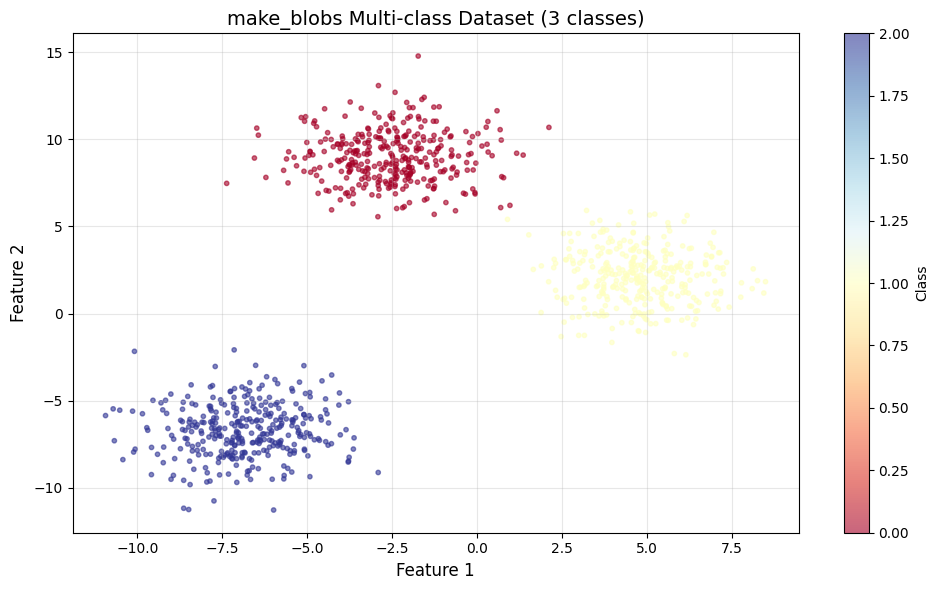

Training size: 800
Test size: 200

Using device: cpu
Epoch [10/100], Loss: 0.2218, Acc: 99.87%
Epoch [20/100], Loss: 0.0491, Acc: 100.00%
Epoch [30/100], Loss: 0.0222, Acc: 100.00%
Epoch [40/100], Loss: 0.0136, Acc: 100.00%
Epoch [50/100], Loss: 0.0101, Acc: 100.00%
Epoch [60/100], Loss: 0.0083, Acc: 100.00%
Epoch [70/100], Loss: 0.0071, Acc: 100.00%
Epoch [80/100], Loss: 0.0062, Acc: 100.00%
Epoch [90/100], Loss: 0.0055, Acc: 100.00%
Epoch [100/100], Loss: 0.0050, Acc: 100.00%

Training complete!

First 3 predictions:

Sample 1:
  Logits: [-2.36807   4.046113 -5.483519]
  Probabilities: [1.6353603e-03 9.9829203e-01 7.2542207e-05]
  Predicted: 1, Actual: 1

Sample 2:
  Logits: [-2.7369232  4.5827665 -3.5122993]
  Probabilities: [6.6172756e-04 9.9903357e-01 3.0474568e-04]
  Predicted: 1, Actual: 1

Sample 3:
  Logits: [ 1.7314725 -0.584315  -6.4799213]
  Probabilities: [9.0995121e-01 8.9801654e-02 2.4709007e-04]
  Predicted: 0, Actual: 0

Test Accuracy: 99.50%


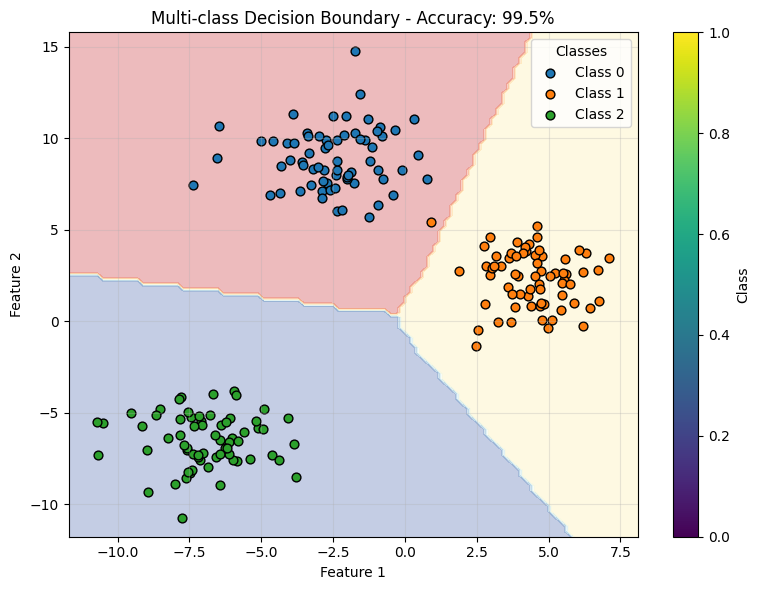

Class 0 Accuracy: 100.00%
Class 1 Accuracy: 98.51%
Class 2 Accuracy: 100.00%


In [21]:
# N_CLASS = 3
# TODO: Create make_blobs dataset
n_samples = 1000
n_classes = 3

X, y = make_blobs(
    n_samples=n_samples,
    n_features=2,
    centers=n_classes,
    cluster_std=1.5,
    random_state=42
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(set(y))}")

for class_id in range(n_classes):
    print(f"  Class {class_id}: {sum(y == class_id)} samples")

# TODO: Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.6)
plt.title(f'make_blobs Multi-class Dataset ({n_classes} classes)', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Class')
plt.tight_layout()
plt.show()

# TODO: Split data (stratified for multi-class)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# TODO: Convert to PyTorch tensors
# IMPORTANT: For multi-class, y should be LongTensor (class indices)
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

# Move to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
# TODO: Define multi-class model
class BlobModel(nn.Module):
    """Multi-class classifier"""
    def __init__(self, input_size=2, hidden_size=16, num_classes=3):
        super(BlobModel, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
            # Note: No softmax here (output is logits)
        )

    def forward(self, x):
        return self.layer_stack(x)

model = BlobModel(input_size=2, hidden_size=16, num_classes=n_classes)
model = model.to(device)

# TODO: Use CrossEntropyLoss for multi-class
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
train_losses = []
train_accuracies = []

model.train()
for epoch in range(epochs):
    # Forward pass
    y_logits = model(X_train)

    # Calculate loss
    loss = criterion(y_logits, y_train)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track metrics
    train_losses.append(loss.item())
    with torch.no_grad():
        y_pred = torch.argmax(y_logits, dim=1)
        accuracy = (y_pred == y_train).float().mean()
        train_accuracies.append(accuracy.item())

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Acc: {accuracy.item()*100:.2f}%')

print("\nTraining complete!")

# Make predictions
model.eval()
with torch.inference_mode():
    test_logits = model(X_test)

    # Convert to probabilities using softmax
    test_probs = torch.softmax(test_logits, dim=1)

    # Convert to labels using argmax
    test_preds = torch.argmax(test_probs, dim=1)

# Show examples
print("\nFirst 3 predictions:")
for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"  Logits: {test_logits[i].cpu().numpy()}")
    print(f"  Probabilities: {test_probs[i].cpu().numpy()}")
    print(f"  Predicted: {test_preds[i].item()}, Actual: {y_test[i].item()}")

# Calculate test accuracy
test_accuracy = (test_preds == y_test).float().mean()
print(f"\nTest Accuracy: {test_accuracy.item()*100:.2f}%")

def plot_multi_class_decision_boundary(model, X, y, title):
    """Plot decision boundary for multi-class model"""
    model.eval()

    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    # Make predictions on meshgrid
    mesh = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    with torch.inference_mode():
        Z = torch.argmax(model(mesh), dim=1).reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z.cpu().numpy(), alpha=0.3, cmap='RdYlBu')
    # Plot each class separately to get legend
    classes = np.unique(y)

    for cls in classes:
        plt.scatter(
            X[y == cls, 0],
            X[y == cls, 1],
            s=40,
            edgecolors='k',
            label=f'Class {cls}'
        )
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.colorbar(label='Class')
    plt.tight_layout()
    plt.legend(title="Classes")
    plt.show()

# Plot decision boundary
X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy()

plot_multi_class_decision_boundary(
    model, X_test_np, y_test_np,
    f'Multi-class Decision Boundary - Accuracy: {test_accuracy.item()*100:.1f}%'
)

for class_id in range(n_classes):
    class_mask = y_test == class_id
    class_acc = (test_preds[class_mask] == y_test[class_mask]).float().mean()
    print(f"Class {class_id} Accuracy: {class_acc.item()*100:.2f}%")

X shape: (1000, 2)
y shape: (1000,)
Number of classes: 5
  Class 0: 200 samples
  Class 1: 200 samples
  Class 2: 200 samples
  Class 3: 200 samples
  Class 4: 200 samples


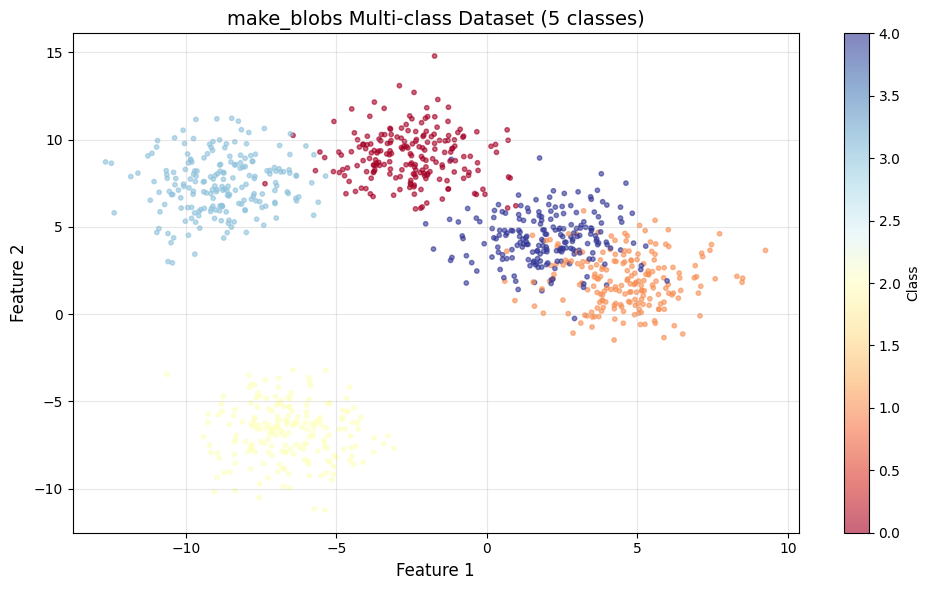

Training size: 800
Test size: 200

Using device: cpu
Epoch [10/100], Loss: 0.8764, Acc: 59.38%
Epoch [20/100], Loss: 0.5453, Acc: 87.63%
Epoch [30/100], Loss: 0.3657, Acc: 91.75%
Epoch [40/100], Loss: 0.2664, Acc: 92.62%
Epoch [50/100], Loss: 0.2215, Acc: 92.37%
Epoch [60/100], Loss: 0.1997, Acc: 92.75%
Epoch [70/100], Loss: 0.1879, Acc: 93.25%
Epoch [80/100], Loss: 0.1820, Acc: 93.50%
Epoch [90/100], Loss: 0.1782, Acc: 93.50%
Epoch [100/100], Loss: 0.1754, Acc: 93.75%

Training complete!

First 3 predictions:

Sample 1:
  Logits: [-8.906157  -6.8441353  6.189557  -5.6283298 -2.8860862]
  Probabilities: [2.77946299e-07 2.18517062e-06 9.99875665e-01 7.37060554e-06
 1.14404764e-04]
  Predicted: 2, Actual: 2

Sample 2:
  Logits: [ 7.404673  -4.7297115 -4.241723  -0.6675494  4.316276 ]
  Probabilities: [9.5611340e-01 5.1358616e-06 8.3664963e-06 2.9839229e-04 4.3574821e-02]
  Predicted: 0, Actual: 0

Sample 3:
  Logits: [-6.0559516  7.172776  -4.2267895 -6.9988313  3.1345098]
  Probabilitie

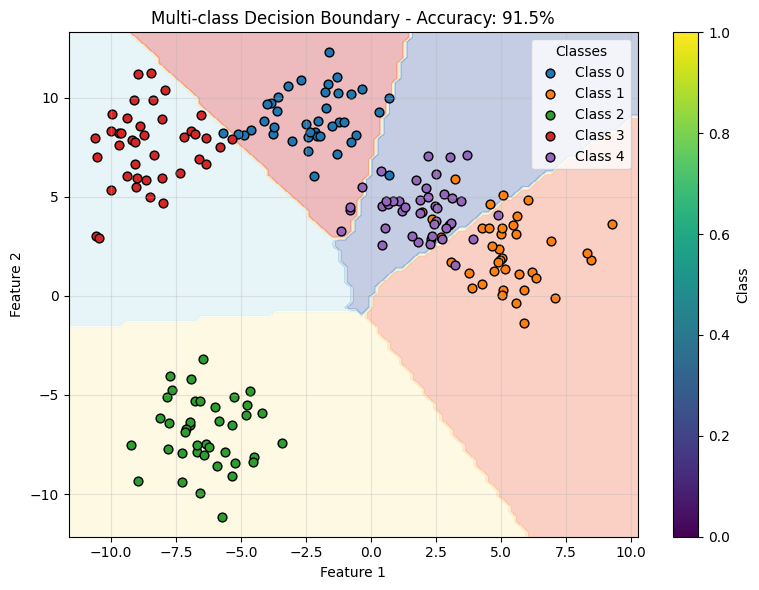

Class 0 Accuracy: 95.00%
Class 1 Accuracy: 80.00%
Class 2 Accuracy: 100.00%
Class 3 Accuracy: 100.00%
Class 4 Accuracy: 82.50%


In [22]:
# N_CLASS = 5
# TODO: Create make_blobs dataset
n_samples = 1000
n_classes = 5

X, y = make_blobs(
    n_samples=n_samples,
    n_features=2,
    centers=n_classes,
    cluster_std=1.5,
    random_state=42
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(set(y))}")

for class_id in range(n_classes):
    print(f"  Class {class_id}: {sum(y == class_id)} samples")

# TODO: Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.6)
plt.title(f'make_blobs Multi-class Dataset ({n_classes} classes)', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Class')
plt.tight_layout()
plt.show()

# TODO: Split data (stratified for multi-class)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# TODO: Convert to PyTorch tensors
# IMPORTANT: For multi-class, y should be LongTensor (class indices)
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

# Move to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
# TODO: Define multi-class model
class BlobModel(nn.Module):
    """Multi-class classifier"""
    def __init__(self, input_size=2, hidden_size=16, num_classes=5):
        super(BlobModel, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
            # Note: No softmax here (output is logits)
        )

    def forward(self, x):
        return self.layer_stack(x)

model = BlobModel(input_size=2, hidden_size=16, num_classes=n_classes)
model = model.to(device)

# TODO: Use CrossEntropyLoss for multi-class
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
train_losses = []
train_accuracies = []

model.train()
for epoch in range(epochs):
    # Forward pass
    y_logits = model(X_train)

    # Calculate loss
    loss = criterion(y_logits, y_train)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track metrics
    train_losses.append(loss.item())
    with torch.no_grad():
        y_pred = torch.argmax(y_logits, dim=1)
        accuracy = (y_pred == y_train).float().mean()
        train_accuracies.append(accuracy.item())

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Acc: {accuracy.item()*100:.2f}%')

print("\nTraining complete!")

# Make predictions
model.eval()
with torch.inference_mode():
    test_logits = model(X_test)

    # Convert to probabilities using softmax
    test_probs = torch.softmax(test_logits, dim=1)

    # Convert to labels using argmax
    test_preds = torch.argmax(test_probs, dim=1)

# Show examples
print("\nFirst 3 predictions:")
for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"  Logits: {test_logits[i].cpu().numpy()}")
    print(f"  Probabilities: {test_probs[i].cpu().numpy()}")
    print(f"  Predicted: {test_preds[i].item()}, Actual: {y_test[i].item()}")

# Calculate test accuracy
test_accuracy = (test_preds == y_test).float().mean()
print(f"\nTest Accuracy: {test_accuracy.item()*100:.2f}%")

def plot_multi_class_decision_boundary(model, X, y, title):
    """Plot decision boundary for multi-class model"""
    model.eval()

    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    # Make predictions on meshgrid
    mesh = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    with torch.inference_mode():
        Z = torch.argmax(model(mesh), dim=1).reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z.cpu().numpy(), alpha=0.3, cmap='RdYlBu')
    # Plot each class separately to get legend
    classes = np.unique(y)

    for cls in classes:
        plt.scatter(
            X[y == cls, 0],
            X[y == cls, 1],
            s=40,
            edgecolors='k',
            label=f'Class {cls}'
        )
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.colorbar(label='Class')
    plt.tight_layout()
    plt.legend(title="Classes")
    plt.show()

# Plot decision boundary
X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy()

plot_multi_class_decision_boundary(
    model, X_test_np, y_test_np,
    f'Multi-class Decision Boundary - Accuracy: {test_accuracy.item()*100:.1f}%'
)

for class_id in range(n_classes):
    class_mask = y_test == class_id
    class_acc = (test_preds[class_mask] == y_test[class_mask]).float().mean()
    print(f"Class {class_id} Accuracy: {class_acc.item()*100:.2f}%")

In [25]:
# Exercise 2: Change cluster standard deviation
print("\nExercise 2: Change cluster overlap")
print("Try different cluster_std values:")
print("  - cluster_std=0.5 (tight clusters)")
print("  - cluster_std=1.5 (default)")
print("  - cluster_std=3.0 (overlapping clusters)")
print("Tip: Modify the 'cluster_std' parameter in make_blobs()")


Exercise 2: Change cluster overlap
Try different cluster_std values:
  - cluster_std=0.5 (tight clusters)
  - cluster_std=1.5 (default)
  - cluster_std=3.0 (overlapping clusters)
Tip: Modify the 'cluster_std' parameter in make_blobs()


X shape: (1000, 2)
y shape: (1000,)
Number of classes: 4
  Class 0: 250 samples
  Class 1: 250 samples
  Class 2: 250 samples
  Class 3: 250 samples


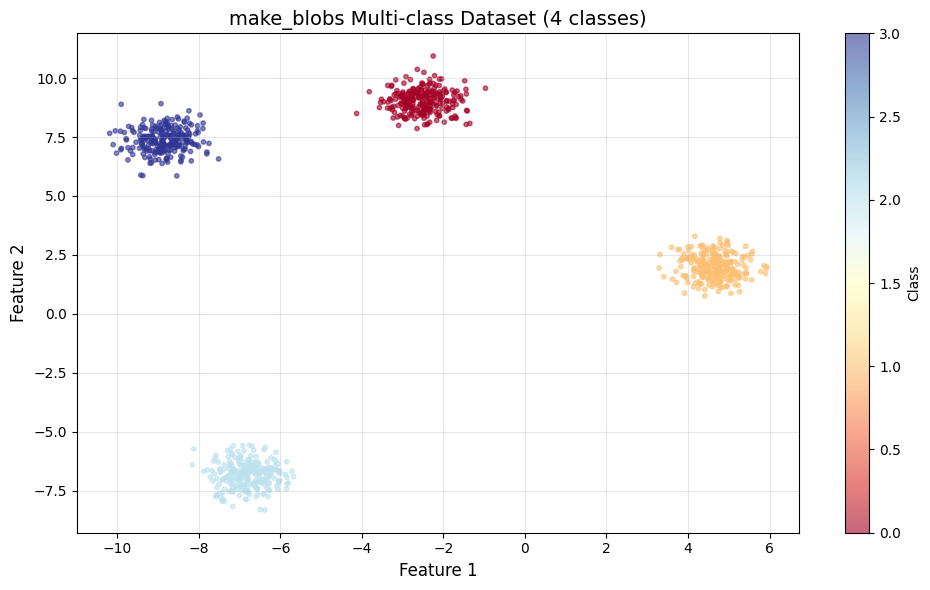

In [23]:
# CLUTER_STD = 0.5
# TODO: Create make_blobs dataset
n_samples = 1000
n_classes = 4

X, y = make_blobs(
    n_samples=n_samples,
    n_features=2,
    centers=n_classes,
    cluster_std=0.5,
    random_state=42
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(set(y))}")

for class_id in range(n_classes):
    print(f"  Class {class_id}: {sum(y == class_id)} samples")

# TODO: Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.6)
plt.title(f'make_blobs Multi-class Dataset ({n_classes} classes)', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Class')
plt.tight_layout()
plt.show()


X shape: (1000, 2)
y shape: (1000,)
Number of classes: 4
  Class 0: 250 samples
  Class 1: 250 samples
  Class 2: 250 samples
  Class 3: 250 samples


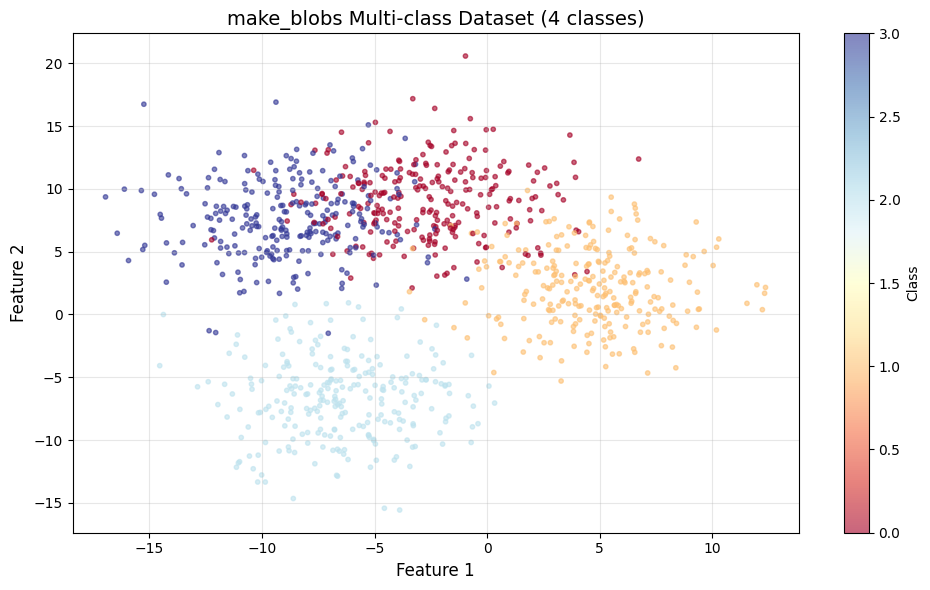

In [24]:
# CLUSTER_STD = 3.0
# CLUTER_STD = 0.5
# TODO: Create make_blobs dataset
n_samples = 1000
n_classes = 4

X, y = make_blobs(
    n_samples=n_samples,
    n_features=2,
    centers=n_classes,
    cluster_std=3,
    random_state=42
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(set(y))}")

for class_id in range(n_classes):
    print(f"  Class {class_id}: {sum(y == class_id)} samples")

# TODO: Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.6)
plt.title(f'make_blobs Multi-class Dataset ({n_classes} classes)', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Class')
plt.tight_layout()
plt.show()


In [27]:
# Exercise 3: Compare binary vs multi-class
print("\nExercise 3: Compare binary vs multi-class")
print("Questions to answer:")
print("  - How is binary different from multi-class?")
# Binary classification: Chỉ có 2 lớp (0 hoặc 1).
# Multi-class classification: Có từ 3 lớp trở lên.
print("  - What's different about the loss function?")
# BCEWithLogitsLoss -> dùng cho 2 lớp.
# CrossEntropyLoss -> dùng cho nhiều lớp.
print("  - What's different about the output activation?")
# Binary -> Sigmoid
# Multi-class ->	Softmax
print("Tip: Look at BCEWithLogitsLoss vs CrossEntropyLoss")


Exercise 3: Compare binary vs multi-class
Questions to answer:
  - How is binary different from multi-class?
  - What's different about the loss function?
  - What's different about the output activation?
Tip: Look at BCEWithLogitsLoss vs CrossEntropyLoss


In [29]:
# Exercise 4: Experiment with model size
print("\nExercise 4: Experiment with model size")
print("Try different model sizes:")
print("  - hidden_size=8")
print("  - hidden_size=16 (default)")
print("  - hidden_size=32")
print("Tip: Modify the 'hidden_size' parameter in BlobModel()")


Exercise 4: Experiment with model size
Try different model sizes:
  - hidden_size=8
  - hidden_size=16 (default)
  - hidden_size=32
Tip: Modify the 'hidden_size' parameter in BlobModel()


X shape: (1000, 2)
y shape: (1000,)
Number of classes: 5
  Class 0: 200 samples
  Class 1: 200 samples
  Class 2: 200 samples
  Class 3: 200 samples
  Class 4: 200 samples


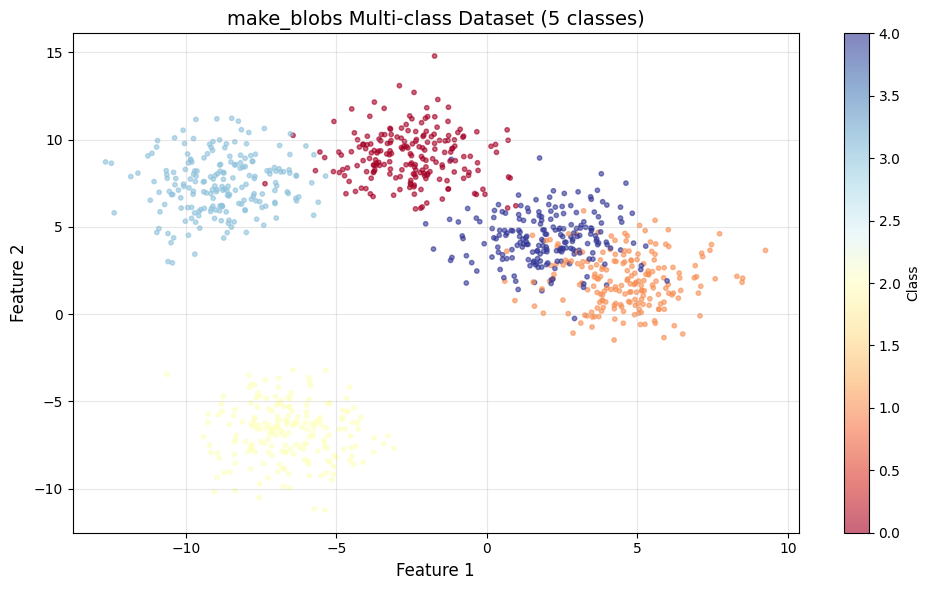

Training size: 800
Test size: 200

Using device: cpu
Epoch [10/100], Loss: 0.9469, Acc: 56.00%
Epoch [20/100], Loss: 0.4362, Acc: 92.37%
Epoch [30/100], Loss: 0.3000, Acc: 92.87%
Epoch [40/100], Loss: 0.2401, Acc: 93.25%
Epoch [50/100], Loss: 0.2115, Acc: 93.25%
Epoch [60/100], Loss: 0.1974, Acc: 93.25%
Epoch [70/100], Loss: 0.1896, Acc: 93.25%
Epoch [80/100], Loss: 0.1845, Acc: 93.37%
Epoch [90/100], Loss: 0.1808, Acc: 93.37%
Epoch [100/100], Loss: 0.1778, Acc: 93.50%

Training complete!

First 3 predictions:

Sample 1:
  Logits: [-14.570446   -6.106064    2.0193877  -5.1248655  -8.041346 ]
  Probabilities: [6.2321362e-08 2.9557748e-04 9.9887317e-01 7.8849797e-04 4.2676536e-05]
  Predicted: 2, Actual: 2

Sample 2:
  Logits: [ 4.2217646 -9.228197  -9.2953825 -3.4941669  1.8284856]
  Probabilities: [9.1593701e-01 1.3201445e-06 1.2343639e-06 4.0820579e-04 8.3652265e-02]
  Predicted: 0, Actual: 0

Sample 3:
  Logits: [-4.9353867  6.1152678 -3.8647325 -7.608712   3.1837122]
  Probabilities

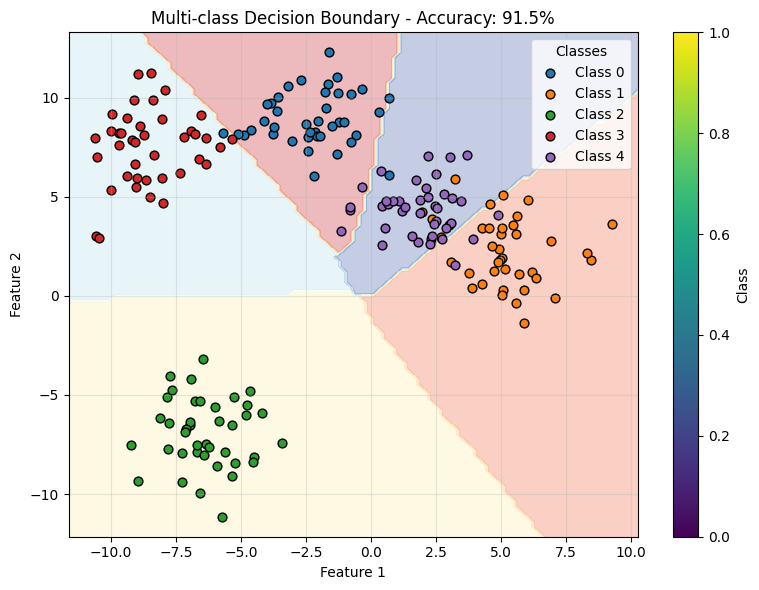

Class 0 Accuracy: 92.50%
Class 1 Accuracy: 82.50%
Class 2 Accuracy: 100.00%
Class 3 Accuracy: 100.00%
Class 4 Accuracy: 82.50%


In [30]:
# hidden_size=8

# TODO: Create make_blobs dataset
n_samples = 1000
n_classes = 5

X, y = make_blobs(
    n_samples=n_samples,
    n_features=2,
    centers=n_classes,
    cluster_std=1.5,
    random_state=42
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(set(y))}")

for class_id in range(n_classes):
    print(f"  Class {class_id}: {sum(y == class_id)} samples")

# TODO: Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.6)
plt.title(f'make_blobs Multi-class Dataset ({n_classes} classes)', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Class')
plt.tight_layout()
plt.show()

# TODO: Split data (stratified for multi-class)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# TODO: Convert to PyTorch tensors
# IMPORTANT: For multi-class, y should be LongTensor (class indices)
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

# Move to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
# TODO: Define multi-class model
class BlobModel(nn.Module):
    """Multi-class classifier"""
    def __init__(self, input_size=2, hidden_size=8, num_classes=5):
        super(BlobModel, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
            # Note: No softmax here (output is logits)
        )

    def forward(self, x):
        return self.layer_stack(x)

model = BlobModel(input_size=2, hidden_size=16, num_classes=n_classes)
model = model.to(device)

# TODO: Use CrossEntropyLoss for multi-class
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
train_losses = []
train_accuracies = []

model.train()
for epoch in range(epochs):
    # Forward pass
    y_logits = model(X_train)

    # Calculate loss
    loss = criterion(y_logits, y_train)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track metrics
    train_losses.append(loss.item())
    with torch.no_grad():
        y_pred = torch.argmax(y_logits, dim=1)
        accuracy = (y_pred == y_train).float().mean()
        train_accuracies.append(accuracy.item())

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Acc: {accuracy.item()*100:.2f}%')

print("\nTraining complete!")

# Make predictions
model.eval()
with torch.inference_mode():
    test_logits = model(X_test)

    # Convert to probabilities using softmax
    test_probs = torch.softmax(test_logits, dim=1)

    # Convert to labels using argmax
    test_preds = torch.argmax(test_probs, dim=1)

# Show examples
print("\nFirst 3 predictions:")
for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"  Logits: {test_logits[i].cpu().numpy()}")
    print(f"  Probabilities: {test_probs[i].cpu().numpy()}")
    print(f"  Predicted: {test_preds[i].item()}, Actual: {y_test[i].item()}")

# Calculate test accuracy
test_accuracy = (test_preds == y_test).float().mean()
print(f"\nTest Accuracy: {test_accuracy.item()*100:.2f}%")

def plot_multi_class_decision_boundary(model, X, y, title):
    """Plot decision boundary for multi-class model"""
    model.eval()

    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    # Make predictions on meshgrid
    mesh = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    with torch.inference_mode():
        Z = torch.argmax(model(mesh), dim=1).reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z.cpu().numpy(), alpha=0.3, cmap='RdYlBu')
    # Plot each class separately to get legend
    classes = np.unique(y)

    for cls in classes:
        plt.scatter(
            X[y == cls, 0],
            X[y == cls, 1],
            s=40,
            edgecolors='k',
            label=f'Class {cls}'
        )
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.colorbar(label='Class')
    plt.tight_layout()
    plt.legend(title="Classes")
    plt.show()

# Plot decision boundary
X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy()

plot_multi_class_decision_boundary(
    model, X_test_np, y_test_np,
    f'Multi-class Decision Boundary - Accuracy: {test_accuracy.item()*100:.1f}%'
)

for class_id in range(n_classes):
    class_mask = y_test == class_id
    class_acc = (test_preds[class_mask] == y_test[class_mask]).float().mean()
    print(f"Class {class_id} Accuracy: {class_acc.item()*100:.2f}%")

X shape: (1000, 2)
y shape: (1000,)
Number of classes: 5
  Class 0: 200 samples
  Class 1: 200 samples
  Class 2: 200 samples
  Class 3: 200 samples
  Class 4: 200 samples


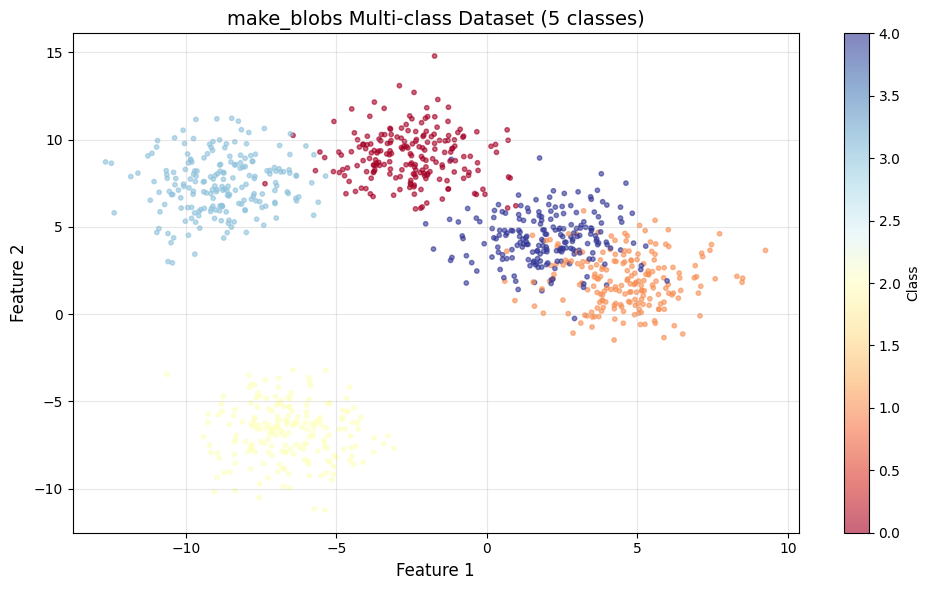

Training size: 800
Test size: 200

Using device: cpu
Epoch [10/100], Loss: 0.3778, Acc: 91.62%
Epoch [20/100], Loss: 0.2266, Acc: 93.25%
Epoch [30/100], Loss: 0.1954, Acc: 92.50%
Epoch [40/100], Loss: 0.1869, Acc: 92.62%
Epoch [50/100], Loss: 0.1817, Acc: 92.87%
Epoch [60/100], Loss: 0.1770, Acc: 93.00%
Epoch [70/100], Loss: 0.1731, Acc: 93.50%
Epoch [80/100], Loss: 0.1699, Acc: 93.75%
Epoch [90/100], Loss: 0.1673, Acc: 93.75%
Epoch [100/100], Loss: 0.1649, Acc: 93.75%

Training complete!

First 3 predictions:

Sample 1:
  Logits: [-7.923751   -2.889916    8.404621   -0.89622056 -5.221702  ]
  Probabilities: [8.1027437e-08 1.2439401e-05 9.9989498e-01 9.1337752e-05 1.2081398e-06]
  Predicted: 2, Actual: 2

Sample 2:
  Logits: [ 6.303935  -1.9929045 -7.588453  -2.8299198  3.2925756]
  Probabilities: [9.52759385e-01 2.37526197e-04 8.82258917e-07 1.02849095e-04
 4.68993075e-02]
  Predicted: 0, Actual: 0

Sample 3:
  Logits: [-7.198067   5.6961913 -3.8102007 -6.465108   1.9010634]
  Probabi

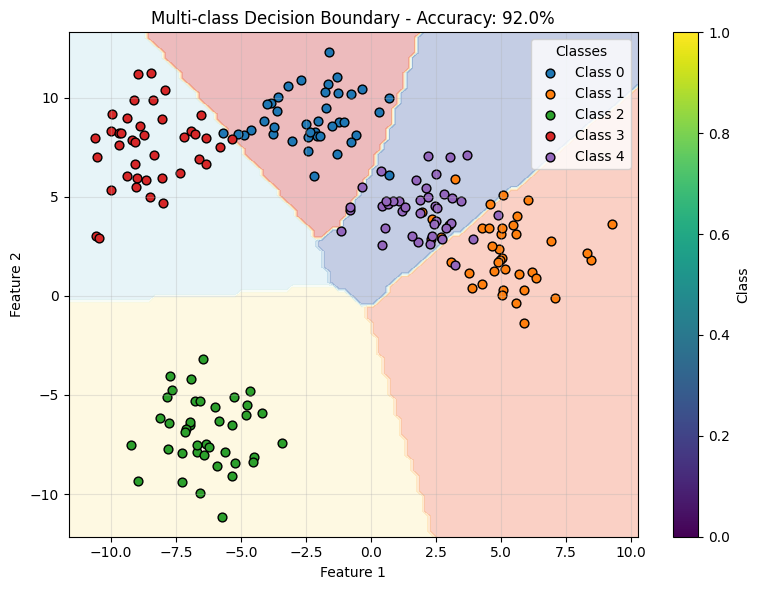

Class 0 Accuracy: 95.00%
Class 1 Accuracy: 80.00%
Class 2 Accuracy: 100.00%
Class 3 Accuracy: 100.00%
Class 4 Accuracy: 85.00%


In [33]:
# hidden_size=32

# TODO: Create make_blobs dataset
n_samples = 1000
n_classes = 5

X, y = make_blobs(
    n_samples=n_samples,
    n_features=2,
    centers=n_classes,
    cluster_std=1.5,
    random_state=42
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(set(y))}")

for class_id in range(n_classes):
    print(f"  Class {class_id}: {sum(y == class_id)} samples")

# TODO: Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.6)
plt.title(f'make_blobs Multi-class Dataset ({n_classes} classes)', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Class')
plt.tight_layout()
plt.show()

# TODO: Split data (stratified for multi-class)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# TODO: Convert to PyTorch tensors
# IMPORTANT: For multi-class, y should be LongTensor (class indices)
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

# Move to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
# TODO: Define multi-class model
class BlobModel(nn.Module):
    """Multi-class classifier"""
    def __init__(self, input_size=2, hidden_size=32, num_classes=5):
        super(BlobModel, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
            # Note: No softmax here (output is logits)
        )

    def forward(self, x):
        return self.layer_stack(x)

model = BlobModel(input_size=2, hidden_size=32, num_classes=n_classes)
model = model.to(device)

# TODO: Use CrossEntropyLoss for multi-class
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
train_losses = []
train_accuracies = []

model.train()
for epoch in range(epochs):
    # Forward pass
    y_logits = model(X_train)

    # Calculate loss
    loss = criterion(y_logits, y_train)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track metrics
    train_losses.append(loss.item())
    with torch.no_grad():
        y_pred = torch.argmax(y_logits, dim=1)
        accuracy = (y_pred == y_train).float().mean()
        train_accuracies.append(accuracy.item())

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Acc: {accuracy.item()*100:.2f}%')

print("\nTraining complete!")

# Make predictions
model.eval()
with torch.inference_mode():
    test_logits = model(X_test)

    # Convert to probabilities using softmax
    test_probs = torch.softmax(test_logits, dim=1)

    # Convert to labels using argmax
    test_preds = torch.argmax(test_probs, dim=1)

# Show examples
print("\nFirst 3 predictions:")
for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"  Logits: {test_logits[i].cpu().numpy()}")
    print(f"  Probabilities: {test_probs[i].cpu().numpy()}")
    print(f"  Predicted: {test_preds[i].item()}, Actual: {y_test[i].item()}")

# Calculate test accuracy
test_accuracy = (test_preds == y_test).float().mean()
print(f"\nTest Accuracy: {test_accuracy.item()*100:.2f}%")

def plot_multi_class_decision_boundary(model, X, y, title):
    """Plot decision boundary for multi-class model"""
    model.eval()

    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    # Make predictions on meshgrid
    mesh = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    with torch.inference_mode():
        Z = torch.argmax(model(mesh), dim=1).reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z.cpu().numpy(), alpha=0.3, cmap='RdYlBu')
    # Plot each class separately to get legend
    classes = np.unique(y)

    for cls in classes:
        plt.scatter(
            X[y == cls, 0],
            X[y == cls, 1],
            s=40,
            edgecolors='k',
            label=f'Class {cls}'
        )
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.colorbar(label='Class')
    plt.tight_layout()
    plt.legend(title="Classes")
    plt.show()

# Plot decision boundary
X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy()

plot_multi_class_decision_boundary(
    model, X_test_np, y_test_np,
    f'Multi-class Decision Boundary - Accuracy: {test_accuracy.item()*100:.1f}%'
)

for class_id in range(n_classes):
    class_mask = y_test == class_id
    class_acc = (test_preds[class_mask] == y_test[class_mask]).float().mean()
    print(f"Class {class_id} Accuracy: {class_acc.item()*100:.2f}%")


Exercise 5: Add more hidden layers
Try deeper architectures:
  - Add another hidden layer
  - Experiment with different widths
Tip: Modify BlobModel to add more layers
X shape: (1000, 2)
y shape: (1000,)
Number of classes: 5
  Class 0: 200 samples
  Class 1: 200 samples
  Class 2: 200 samples
  Class 3: 200 samples
  Class 4: 200 samples


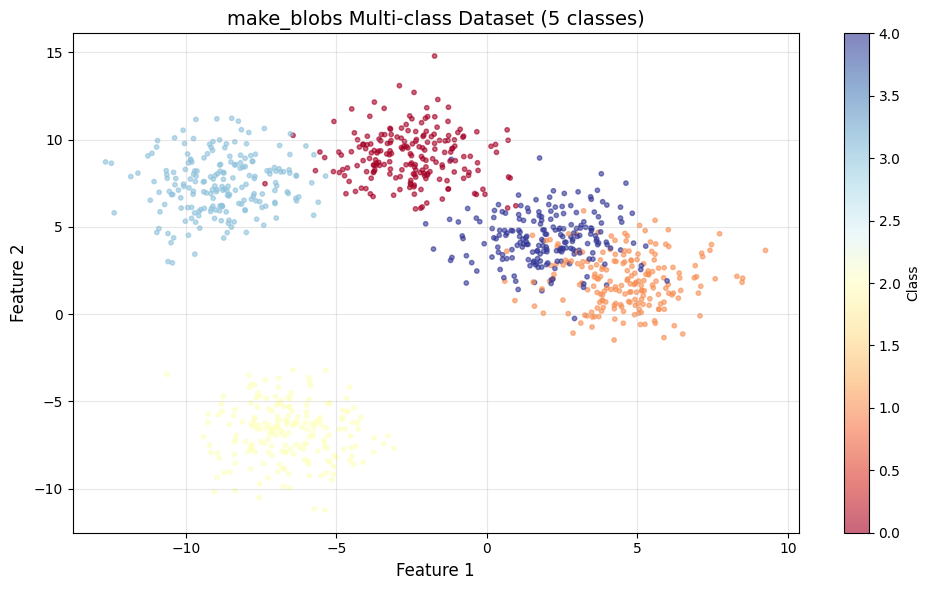

Training size: 800
Test size: 200

Using device: cpu
Epoch [10/100], Loss: 0.3495, Acc: 92.37%
Epoch [20/100], Loss: 0.1986, Acc: 92.75%
Epoch [30/100], Loss: 0.1849, Acc: 93.12%
Epoch [40/100], Loss: 0.1747, Acc: 93.25%
Epoch [50/100], Loss: 0.1658, Acc: 93.50%
Epoch [60/100], Loss: 0.1567, Acc: 93.75%
Epoch [70/100], Loss: 0.1521, Acc: 94.25%
Epoch [80/100], Loss: 0.1485, Acc: 94.38%
Epoch [90/100], Loss: 0.1466, Acc: 94.50%
Epoch [100/100], Loss: 0.1451, Acc: 94.88%

Training complete!

First 3 predictions:

Sample 1:
  Logits: [-12.716054  -5.43567    9.396277  -2.662784  -5.125234]
  Probabilities: [2.4930649e-10 3.6187970e-07 9.9999332e-01 5.7917982e-06 4.9361114e-07]
  Predicted: 2, Actual: 2

Sample 2:
  Logits: [  5.9061875  -6.057141  -12.927085   -5.1998253   1.0583104]
  Probabilities: [9.9219501e-01 6.3239663e-06 6.5676580e-09 1.4904491e-05 7.7837841e-03]
  Predicted: 0, Actual: 0

Sample 3:
  Logits: [-8.047086  10.330035  -7.310811  -9.59492    6.9652314]
  Probabilities

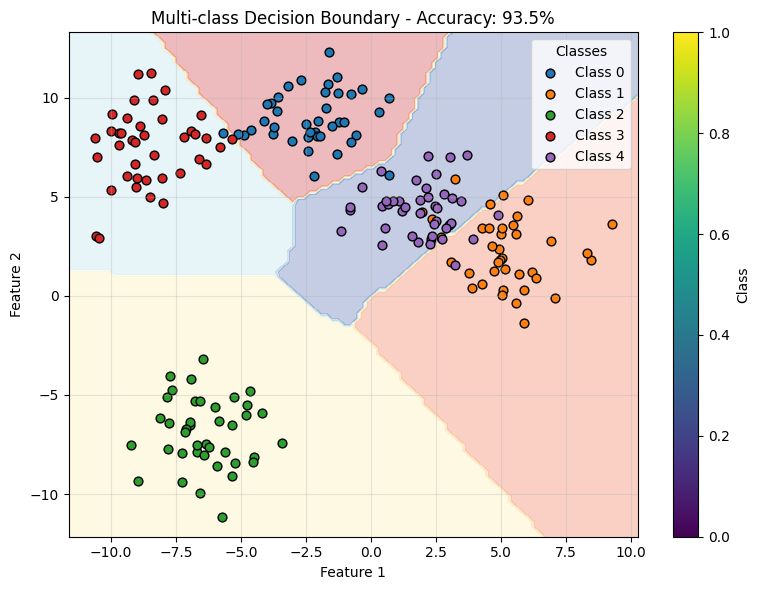

Class 0 Accuracy: 95.00%
Class 1 Accuracy: 80.00%
Class 2 Accuracy: 100.00%
Class 3 Accuracy: 100.00%
Class 4 Accuracy: 92.50%


In [34]:
# Exercise 5: Add more hidden layers
print("\nExercise 5: Add more hidden layers")
print("Try deeper architectures:")
print("  - Add another hidden layer")
print("  - Experiment with different widths")
print("Tip: Modify BlobModel to add more layers")

# hidden_size=32

# TODO: Create make_blobs dataset
n_samples = 1000
n_classes = 5

X, y = make_blobs(
    n_samples=n_samples,
    n_features=2,
    centers=n_classes,
    cluster_std=1.5,
    random_state=42
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(set(y))}")

for class_id in range(n_classes):
    print(f"  Class {class_id}: {sum(y == class_id)} samples")

# TODO: Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.6)
plt.title(f'make_blobs Multi-class Dataset ({n_classes} classes)', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Class')
plt.tight_layout()
plt.show()

# TODO: Split data (stratified for multi-class)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# TODO: Convert to PyTorch tensors
# IMPORTANT: For multi-class, y should be LongTensor (class indices)
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

# Move to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
# TODO: Define multi-class model
class BlobModel(nn.Module):
    """Multi-class classifier"""
    def __init__(self, input_size=2, hidden_size=32, num_classes=5):
        super(BlobModel, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
            # Note: No softmax here (output is logits)
        )

    def forward(self, x):
        return self.layer_stack(x)

model = BlobModel(input_size=2, hidden_size=32, num_classes=n_classes)
model = model.to(device)

# TODO: Use CrossEntropyLoss for multi-class
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
train_losses = []
train_accuracies = []

model.train()
for epoch in range(epochs):
    # Forward pass
    y_logits = model(X_train)

    # Calculate loss
    loss = criterion(y_logits, y_train)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track metrics
    train_losses.append(loss.item())
    with torch.no_grad():
        y_pred = torch.argmax(y_logits, dim=1)
        accuracy = (y_pred == y_train).float().mean()
        train_accuracies.append(accuracy.item())

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Acc: {accuracy.item()*100:.2f}%')

print("\nTraining complete!")

# Make predictions
model.eval()
with torch.inference_mode():
    test_logits = model(X_test)

    # Convert to probabilities using softmax
    test_probs = torch.softmax(test_logits, dim=1)

    # Convert to labels using argmax
    test_preds = torch.argmax(test_probs, dim=1)

# Show examples
print("\nFirst 3 predictions:")
for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"  Logits: {test_logits[i].cpu().numpy()}")
    print(f"  Probabilities: {test_probs[i].cpu().numpy()}")
    print(f"  Predicted: {test_preds[i].item()}, Actual: {y_test[i].item()}")

# Calculate test accuracy
test_accuracy = (test_preds == y_test).float().mean()
print(f"\nTest Accuracy: {test_accuracy.item()*100:.2f}%")

def plot_multi_class_decision_boundary(model, X, y, title):
    """Plot decision boundary for multi-class model"""
    model.eval()

    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    # Make predictions on meshgrid
    mesh = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    with torch.inference_mode():
        Z = torch.argmax(model(mesh), dim=1).reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z.cpu().numpy(), alpha=0.3, cmap='RdYlBu')
    # Plot each class separately to get legend
    classes = np.unique(y)

    for cls in classes:
        plt.scatter(
            X[y == cls, 0],
            X[y == cls, 1],
            s=40,
            edgecolors='k',
            label=f'Class {cls}'
        )
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.colorbar(label='Class')
    plt.tight_layout()
    plt.legend(title="Classes")
    plt.show()

# Plot decision boundary
X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy()

plot_multi_class_decision_boundary(
    model, X_test_np, y_test_np,
    f'Multi-class Decision Boundary - Accuracy: {test_accuracy.item()*100:.1f}%'
)

for class_id in range(n_classes):
    class_mask = y_test == class_id
    class_acc = (test_preds[class_mask] == y_test[class_mask]).float().mean()
    print(f"Class {class_id} Accuracy: {class_acc.item()*100:.2f}%")

In [32]:
print("\n" + "=" * 60)
print("Exercise 4 Complete!")
print("Remember: If in doubt, run the code!")
print("Remember: Experiment, experiment, experiment!")
print("Remember: Visualize, visualize, visualize!")
print("=" * 60)


Exercise 4 Complete!
Remember: If in doubt, run the code!
Remember: Experiment, experiment, experiment!
Remember: Visualize, visualize, visualize!
